# Sentiment Classification Using TinyBERT Transformer

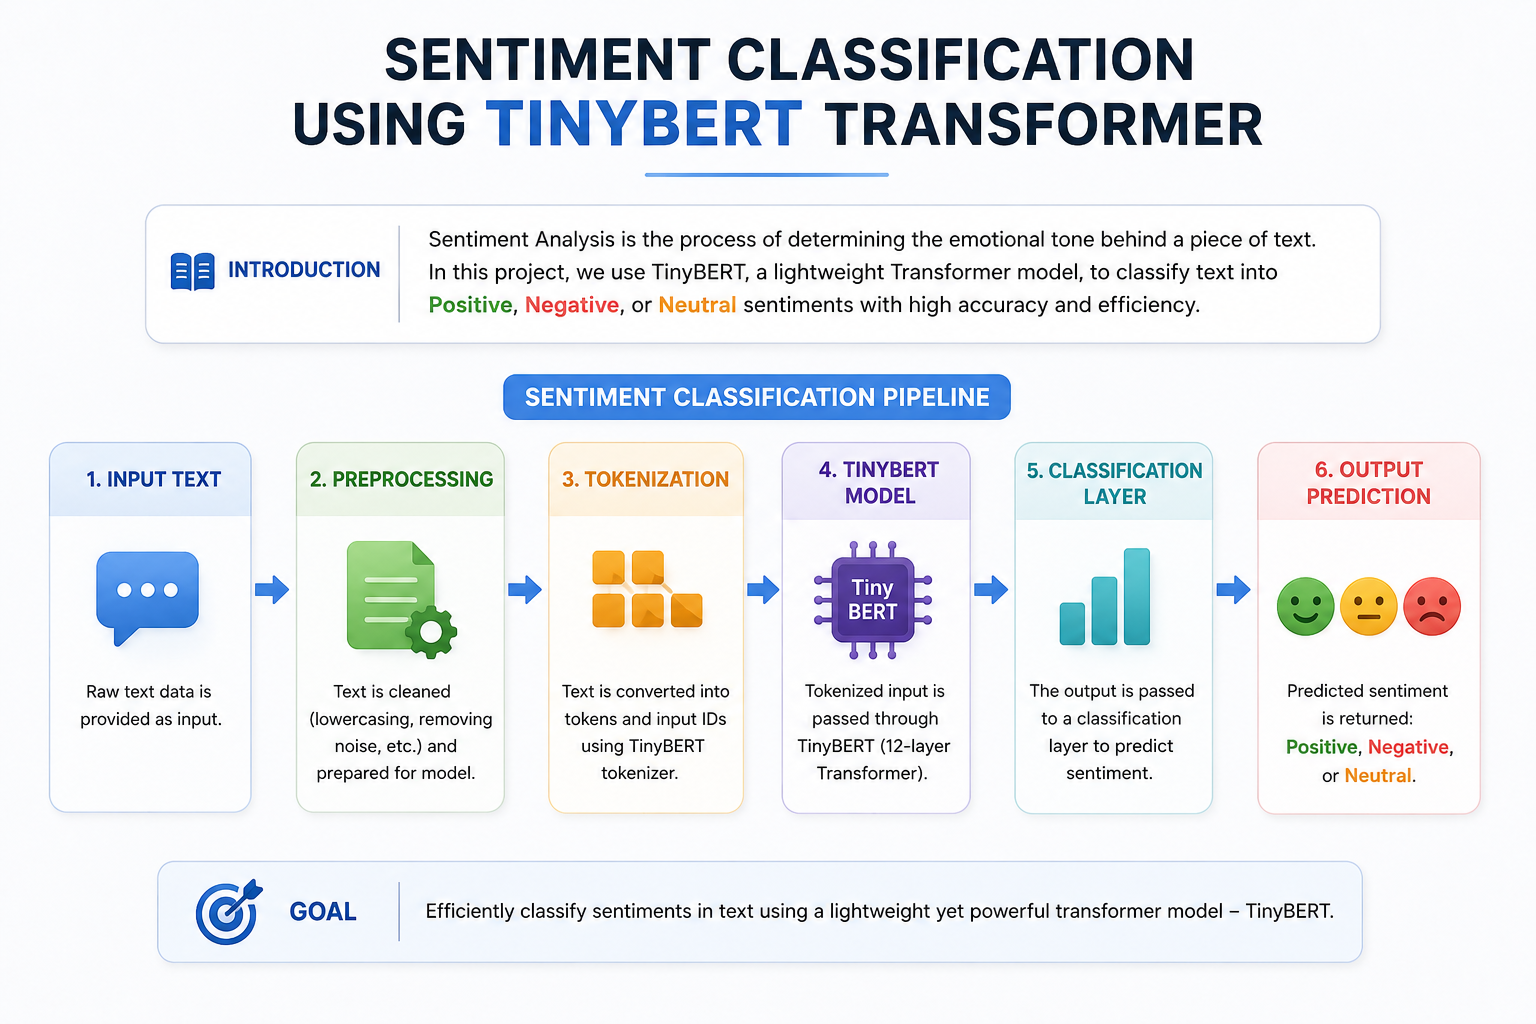

# Load Data

## Load Data With Hugging Face Dataset Library

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/refs/heads/master/IMDB-Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# !pip install datasets

In [4]:
from datasets import Dataset

In [5]:
dataset = Dataset.from_pandas(data)
dataset = dataset.train_test_split(test_size=0.3)
dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 35000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 15000
    })
})

In [6]:
# input_ids, attention_mask, lable --> number

data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
label2id = {'negative':0, 'positive':1}
id2label = {0:'negative', 1:'positive'}

dataset = dataset.map(lambda x: {'label':label2id[x['sentiment']]})

Map: 100%|██████████| 15000/15000 [00:05<00:00, 2908.32 examples/s]


In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment', 'label'],
        num_rows: 35000
    })
    test: Dataset({
        features: ['review', 'sentiment', 'label'],
        num_rows: 15000
    })
})

In [9]:
dataset['train'][0]

{'review': "I always follow the Dakar, so when my husband bought Charlie's 'Race to Dakar' DVD home I couldn't wait to watch it! Of course we'd seen the broadcast of the race when the actual race was on, but that never gives the background and specific teams.<br /><br />If you watched Long Way Round then you won't be surprised by the language which frankly I find more amusing than offensive.<br /><br />I think the only thing that annoyed me about the DVD was Charlie's hair, but he had it styled before Dakar so my feminine need for neatness was assuaged; tho' I could have lived without the 'flame' undies lol As with LWR, the preparation was every bit as interesting as the race itself. I nearly cried when Charlie broke his hand, and winced at every bruise he sustained while training....and of course the death of Andy Caldicott...that was an appalling tragedy, but then every year there's something.<br /><br />Russ drives me nuts, although his attitude has improved a thousand times from th

# Data Tokenization

In [10]:
from transformers import AutoTokenizer
import torch

In [11]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

model_ckpt = 'huawei-noah/TinyBERT_General_4L_312D'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt, use_fast = True)

cuda


In [12]:
tokenizer(dataset['train'][0]['review'])

{'input_ids': [101, 1045, 2467, 3582, 1996, 4830, 6673, 1010, 2061, 2043, 2026, 3129, 4149, 4918, 1005, 1055, 1005, 2679, 2000, 4830, 6673, 1005, 4966, 2188, 1045, 2481, 1005, 1056, 3524, 2000, 3422, 2009, 999, 1997, 2607, 2057, 1005, 1040, 2464, 1996, 3743, 1997, 1996, 2679, 2043, 1996, 5025, 2679, 2001, 2006, 1010, 2021, 2008, 2196, 3957, 1996, 4281, 1998, 3563, 2780, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 2065, 2017, 3427, 2146, 2126, 2461, 2059, 2017, 2180, 1005, 1056, 2022, 4527, 2011, 1996, 2653, 2029, 19597, 1045, 2424, 2062, 19142, 2084, 5805, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1045, 2228, 1996, 2069, 2518, 2008, 11654, 2033, 2055, 1996, 4966, 2001, 4918, 1005, 1055, 2606, 1010, 2021, 2002, 2018, 2009, 13650, 2077, 4830, 6673, 2061, 2026, 12320, 2342, 2005, 15708, 2791, 2001, 4632, 6692, 5999, 1025, 27793, 1005, 1045, 2071, 2031, 2973, 2302, 1996, 1005, 8457, 1005, 6151, 3111, 8840, 2140, 2004, 2007, 1048, 13088, 1010, 1996, 7547, 2001, 2296, 2

In [13]:
def tokenize(batch):
    temp = tokenizer(batch['review'], padding=True, truncation = True, max_length=300)
    return temp

dataset = dataset.map(tokenize, batched=True, batch_size = None)

Map: 100%|██████████| 15000/15000 [00:18<00:00, 793.54 examples/s]


In [14]:
dataset['train'][0].keys()

dict_keys(['review', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])

# Building Model Evaluation Functions

In [15]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

In [16]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

2.2.2+cu121
4.46.3


# Model Building and Training

In [17]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="out",
    logging_dir="logs",
    report_to="none",      # TensorBoard disable
    logging_strategy="steps",
    logging_steps=50,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    evaluation_strategy="epoch",   
    save_strategy="epoch",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

In [30]:
trainer.train()

  2%|▏         | 50/3282 [01:41<1:56:13,  2.16s/it]

{'loss': 0.6838, 'grad_norm': 3.5912768840789795, 'learning_rate': 1.9695307739183427e-05, 'epoch': 0.05}


  3%|▎         | 100/3282 [03:19<1:44:22,  1.97s/it]

{'loss': 0.5772, 'grad_norm': 7.42074728012085, 'learning_rate': 1.9390615478366852e-05, 'epoch': 0.09}


  5%|▍         | 150/3282 [04:59<1:45:39,  2.02s/it]

...

                                                     
100%|██████████| 3282/3282 [2:01:53<00:00,  2.01s/it]

{'eval_loss': 0.297394335269928, 'eval_accuracy': 0.8812666666666666, 'eval_runtime': 309.7716, 'eval_samples_per_second': 48.423, 'eval_steps_per_second': 1.514, 'epoch': 3.0}


100%|██████████| 3282/3282 [2:01:55<00:00,  2.23s/it]

{'train_runtime': 7315.6331, 'train_samples_per_second': 14.353, 'train_steps_per_second': 0.449, 'train_loss': 0.3159478267179183, 'epoch': 3.0}


TrainOutput(global_step=3282, training_loss=0.3159478267179183, metrics={'train_runtime': 7315.6331, 'train_samples_per_second': 14.353, 'train_steps_per_second': 0.449, 'total_flos': 882184338000000.0, 'train_loss': 0.3159478267179183, 'epoch': 3.0})

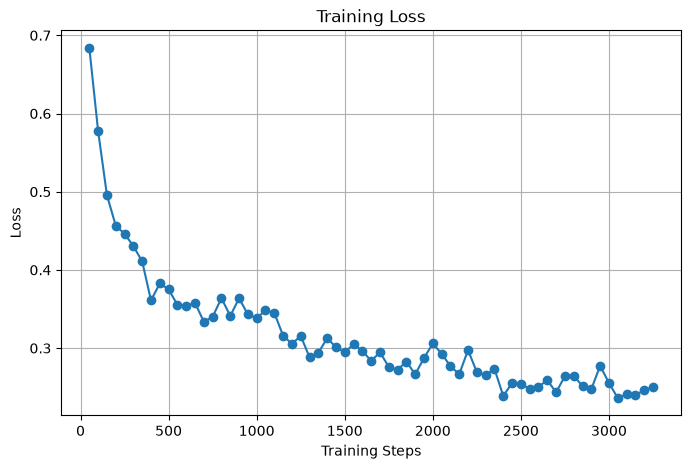

In [33]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss, marker="o")
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

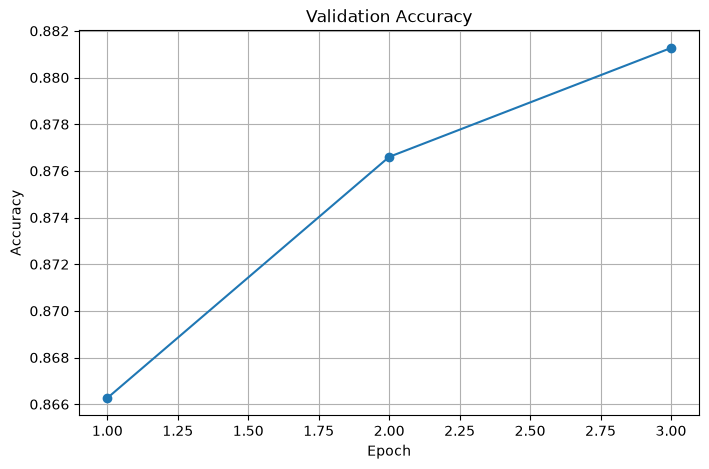

In [34]:
eval_acc = []
epochs = []

for log in trainer.state.log_history:
    if "eval_accuracy" in log:
        eval_acc.append(log["eval_accuracy"])
        epochs.append(log["epoch"])

plt.figure(figsize=(8,5))
plt.plot(epochs, eval_acc, marker="o")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

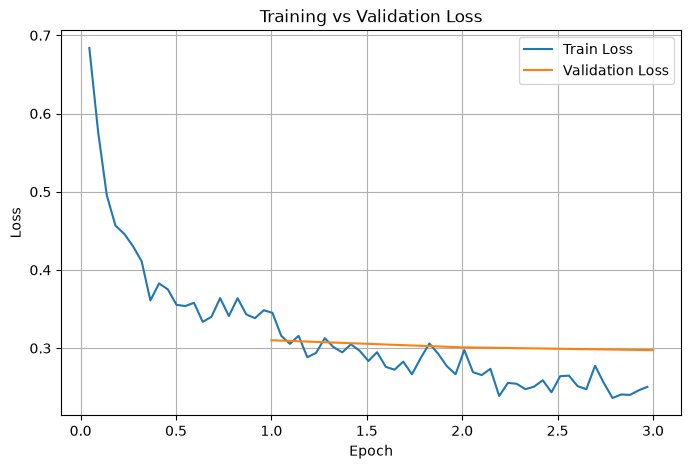

In [35]:
train_epochs = []
train_loss = []
eval_epochs = []
eval_loss = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_epochs.append(log["epoch"])
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
history = pd.DataFrame(trainer.state.log_history)

print(history.columns)
history.head()

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_accuracy', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'train_runtime', 'train_samples_per_second',
       'train_steps_per_second', 'total_flos', 'train_loss'],
      dtype='str')


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.6838,3.591277,0.000020,0.045704,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5772,7.420747,0.000019,0.091408,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.4954,5.878272,0.000019,0.137112,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.4565,7.908751,0.000019,0.182815,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.4462,20.869808,0.000018,0.228519,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Model Save and Load for Inference

In [ ]:
trainer.save_model('tinybert_sentiment_analysis')